## Importing libraries and files and inspecting files

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

price_file = Path("/Users/rohankhanna/Documents/track3_agritech_dataset_files/track3_price_and_msp.json")

print("File exists:", price_file.is_file())
df_prices = pd.read_json(price_file, convert_dates=False)
df_prices_clean = df_prices.copy(deep=True)

print("Rows:", len(df_prices_clean))
print("Exact duplicates:", df_prices_clean.duplicated().sum())

display(df_prices_clean.head(10))

File exists: True
Rows: 12000
Exact duplicates: 0


,record_id,date,mandi_id,district,crop_name,min_price,max_price,modal_price,msp
0,PR001650,2026/07/26,MANDI005,NaN,Kapas,6850.985817820893,"₹7,570.17",7210.58,"₹6,620.00"
1,PR000246,2026-07-17,MANDI028,Fatehabad,कपास,"₹6,944.79",7654.18,"Rs. 7,299",
2,PR010091,09.01.2026,MANDI011,Jalandhar,Dhaan,"Rs. 1,857",2013.18,"₹1,935.06","INR 2,183"
3,PR000982,2026/05/24,M012,Ferozepur,corn,"₹1,873.34","Rs. 1,986","Rs. 1,930","Rs. 2,090"
4,PR001708,18/08/2026,013,Karnal,Cotton,"5,878.62/-",6574.283051769212,6226.45,"Rs. 6,620"
5,PR004312,01-24-2026,MANDI001,Patiala,Kapas,,"₹7,324.58",,"6,620.00/-"
6,PR000288,08-Aug-2026,M031,Hisar,Kanak,"₹2,270.14",2823.4429693584902,"2,546.79/-","₹2,275.00"
7,PR002536,2026-01-06,M036,Kurukshetra,WHEAT,"₹1,961.63","Rs. 2,340","INR 2,151",2275
8,PR009427,12-Aug-2026,MANDI-050,,Gehun,2277.53,"INR 2,458","₹2,367.64","2,275.00/-"
9,PR003418,09.02.2026,M011,Ambala,गन्ना,"₹3,156.94",3890.02,,"Rs. 3,500"


## Inspecting 

In [6]:
price_columns = ["min_price", "max_price", "modal_price", "msp"]

print("Sample price values:")
display(df_prices_clean[price_columns].head(15))

# Temporary inspection only; original values remain unchanged.
inspection = df_prices_clean.replace(r"^\s*$", pd.NA, regex=True)

print("\nMissing values:")
display(
    inspection.isna().sum().to_frame("missing_count")
)

print("\nExact duplicate rows:", df_prices_clean.duplicated().sum())

Sample price values:


,min_price,max_price,modal_price,msp
0,6850.985817820893,"₹7,570.17",7210.58,"₹6,620.00"
1,"₹6,944.79",7654.18,"Rs. 7,299",
2,"Rs. 1,857",2013.18,"₹1,935.06","INR 2,183"
3,"₹1,873.34","Rs. 1,986","Rs. 1,930","Rs. 2,090"
4,"5,878.62/-",6574.283051769212,6226.45,"Rs. 6,620"
5,,"₹7,324.58",,"6,620.00/-"
6,"₹2,270.14",2823.4429693584902,"2,546.79/-","₹2,275.00"
7,"₹1,961.63","Rs. 2,340","INR 2,151",2275
8,2277.53,"INR 2,458","₹2,367.64","2,275.00/-"
9,"₹3,156.94",3890.02,,"Rs. 3,500"



Missing values:


,missing_count
record_id,0
date,0
mandi_id,1235
district,1546
crop_name,0
min_price,598
max_price,598
modal_price,610
msp,2377



Exact duplicate rows: 0


## Checking if prices are internally consistent

In [7]:
price_columns = ["min_price", "max_price", "modal_price", "msp"]

checks = []

for column in price_columns:
    original = (
        df_prices_clean[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

    cleaned = (
        original
        .str.replace(r"(?i)^(?:₹|rs\.?|inr)\s*", "", regex=True)
        .str.replace(r"/-\s*$", "", regex=True)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

    numeric = pd.to_numeric(cleaned, errors="coerce")

    df_prices_clean[f"{column}_clean"] = numeric

    checks.append({
        "column": column,
        "original_missing": int(original.isna().sum()),
        "failed_conversion": int(
            (original.notna() & numeric.isna()).sum()
        ),
        "nonpositive_values": int(numeric.le(0).sum())
    })

display(pd.DataFrame(checks))

,column,original_missing,failed_conversion,nonpositive_values
0,min_price,598,0,0
1,max_price,598,0,0
2,modal_price,610,0,0
3,msp,2377,0,0


In [8]:
minimum = df_prices_clean["min_price_clean"]
maximum = df_prices_clean["max_price_clean"]
modal = df_prices_clean["modal_price_clean"]

# Compare only when both required values are available.
df_prices_clean["min_exceeds_max"] = (
    minimum.notna() & maximum.notna() & minimum.gt(maximum)
).fillna(False)

df_prices_clean["modal_below_min"] = (
    modal.notna() & minimum.notna() & modal.lt(minimum)
).fillna(False)

df_prices_clean["modal_above_max"] = (
    modal.notna() & maximum.notna() & modal.gt(maximum)
).fillna(False)

check_columns = [
    "min_exceeds_max",
    "modal_below_min",
    "modal_above_max"
]

display(
    df_prices_clean[check_columns]
    .sum()
    .to_frame("flagged_rows")
)

,flagged_rows
min_exceeds_max,0
modal_below_min,0
modal_above_max,0


## Inspecting crop names

In [9]:
display(
    df_prices_clean["crop_name"]
    .value_counts(dropna=False)
    .to_frame("row_count")
)

,row_count
crop_name,
Kapas,442
Ganna,442
गन्ना,415
Sarso,414
सरसों,412
Narma,412
sugarcane,404
Sarson,403
Cotton,394


## Mapping crops

In [10]:
crop_groups = {
    "Wheat": ["wheat", "गेहूं", "gehun", "kanak"],
    "Rice": ["rice", "paddy", "chawal", "चावल", "धान", "dhaan", "basmati"],
    "Maize": ["maize", "corn", "मक्का", "makka", "makki"],
    "Mustard": ["mustard", "sarson", "sarso", "सरसों"],
    "Cotton": ["cotton", "कपास", "narma", "kapas"],
    "Sugarcane": ["sugarcane", "गन्ना", "ganna", "ganne"]
}

crop_mapping = {
    spelling: crop
    for crop, spellings in crop_groups.items()
    for spelling in spellings
}

crop_key = (
    df_prices_clean["crop_name"]
    .astype("string")
    .str.normalize("NFC")
    .str.strip()
    .str.casefold()
)

df_prices_clean["crop_name_clean"] = crop_key.map(crop_mapping)

print(
    "Unmapped crop rows:",
    df_prices_clean["crop_name_clean"].isna().sum()
)

display(
    df_prices_clean["crop_name_clean"]
    .value_counts()
    .to_frame("row_count")
)

Unmapped crop rows: 0


,row_count
crop_name_clean,
Maize,2064
Sugarcane,2014
Mustard,2011
Cotton,1996
Wheat,1983
Rice,1932


## Standarizing Mandi ID's

In [11]:
ids = (
    df_prices_clean["mandi_id"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace("", pd.NA)
    .str.replace(r"[\s_-]+", "", regex=True)
)

numbers = ids.str.extract(
    r"^(?:MANDI|M)?(\d{1,3})$",
    expand=False
)

df_prices_clean["mandi_id_clean"] = (
    "MANDI" + numbers.str.zfill(3)
)

## Loading Masters and validating

In [14]:
df_master_clean = pd.read_csv(
    "/Users/rohankhanna/Documents/datathon/cleaned_data/"
    "mandi_master_cleaned.csv",
    dtype={"mandi_id": "string"},
    na_values=["NA"]
)

# Standardize missing IDs without inventing replacements.
df_prices_clean["mandi_id_clean"] = (
    df_prices_clean["mandi_id_clean"]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "NA": pd.NA})
    .fillna(pd.NA)
)

source_ids = (
    df_prices_clean["mandi_id"]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "NA": pd.NA})
)

clean_ids = df_prices_clean["mandi_id_clean"]

df_prices_clean["mandi_id_status"] = np.select(
    [
        source_ids.isna().to_numpy(dtype=bool),
        clean_ids.isna().to_numpy(dtype=bool),
        (~clean_ids.isin(df_master_clean["mandi_id"])).to_numpy(dtype=bool)
    ],
    [
        "Missing source ID",
        "Unrecognized format",
        "Not found in master"
    ],
    default="Matched"
)

display(
    df_prices_clean["mandi_id_status"]
    .value_counts()
    .to_frame("row_count")
)

,row_count
mandi_id_status,
Matched,10765
Missing source ID,1235


## Compare the price districts with master districts

In [ ]:
# Standardize the district supplied in the prices file.
df_prices_clean["district_source_clean"] = (
    df_prices_clean["district"]
    .astype("string")
    .str.strip()
    .str.title()
    .replace("", pd.NA)
)

# Look up the district using the matched mandi ID.
district_lookup = df_master_clean.set_index("mandi_id")["district"]

df_prices_clean["district_from_master"] = (
    df_prices_clean["mandi_id_clean"].map(district_lookup)
)

source = df_prices_clean["district_source_clean"]
master = df_prices_clean["district_from_master"]

df_prices_clean["district_status"] = np.select(
    [
        df_prices_clean["mandi_id_status"]
        .ne("Matched").to_numpy(dtype=bool),

        master.isna().to_numpy(dtype=bool),

        source.isna().to_numpy(dtype=bool),

        source.eq(master).fillna(False).to_numpy(dtype=bool)
    ],
    [
        "Cannot verify: no matched mandi",
        "Unresolved: district missing in master",
        "Recoverable from master",
        "Agrees with master"
    ],
    default="Conflicts with master"
)

display(
    df_prices_clean["district_status"]
    .value_counts()
    .to_frame("row_count")
)

,row_count
district_status,
Conflicts with master,8366
Recoverable from master,1275
Cannot verify: no matched mandi,1235
Unresolved: district missing in master,769
Agrees with master,355


## 8,366 price records disagree with the master district. That’s a substantial data-quality issue, so we’ll preserve the supplied districts and the conflict flags.

In [17]:
# Reporting district comes from the matched mandi master.
df_prices_clean["district_clean"] = (
    df_prices_clean["district_from_master"].copy()
)

print(
    "Records with reporting district:",
    df_prices_clean["district_clean"].notna().sum()
)

print(
    "Records without reporting district:",
    df_prices_clean["district_clean"].isna().sum()
)

Records with reporting district: 9996
Records without reporting district: 2004


## Inspecting dates formats

In [18]:
dates = df_prices_clean["date"].astype("string").str.strip()

display(
    dates.str.replace(r"\d", "D", regex=True)
    .value_counts(dropna=False)
    .to_frame("row_count")
)

display(dates.drop_duplicates().head(15).to_frame("sample_date"))

,row_count
date,
DDDD-DD-DD,2434
DD/DD/DDDD,2367
DD.DD.DDDD,1821
DDDD/DD/DD,1787
DD-DD-DDDD,1752
DD-Feb-DDDD,232
DD-Aug-DDDD,231
DD-Jul-DDDD,231
DD-May-DDDD,229


,sample_date
0,2026/07/26
1,2026-07-17
2,09.01.2026
3,2026/05/24
4,18/08/2026
5,01-24-2026
6,08-Aug-2026
7,2026-01-06
8,12-Aug-2026
9,09.02.2026


## Same datastructures as arrivals , before using the parsing rules we are checking whether the day/month conventions also matched

In [19]:
dates = df_prices_clean["date"].astype("string").str.strip()

for separator in ["/", ".", "-"]:
    parts = dates.str.extract(
        rf"^(\d{{2}})[{separator}](\d{{2}})[{separator}](\d{{4}})$"
    )

    first = pd.to_numeric(parts[0], errors="coerce")
    second = pd.to_numeric(parts[1], errors="coerce")

    print(f"\nSeparator: {separator}")
    print("First number > 12:", int(first.gt(12).sum()))
    print("Second number > 12:", int(second.gt(12).sum()))


Separator: /
First number > 12: 1410
Second number > 12: 0

Separator: .
First number > 12: 1076
Second number > 12: 0

Separator: -
First number > 12: 0
Second number > 12: 995


## Same conventions as arrivals

In [23]:
formats = {
    r"\d{4}-\d{2}-\d{2}": "%Y-%m-%d",
    r"\d{4}/\d{2}/\d{2}": "%Y/%m/%d",
    r"\d{2}/\d{2}/\d{4}": "%d/%m/%Y",
    r"\d{2}\.\d{2}\.\d{4}": "%d.%m.%Y",
    r"\d{2}-\d{2}-\d{4}": "%m-%d-%Y",
    r"\d{2}-[A-Za-z]{3}-\d{4}": "%d-%b-%Y"
}

df_prices_clean["date_clean"] = pd.NaT

for pattern, date_format in formats.items():
    mask = dates.str.fullmatch(pattern, na=False)
    df_prices_clean.loc[mask, "date_clean"] = pd.to_datetime(
        dates.loc[mask], format=date_format, errors="coerce"
    )

# Find dates whose day and month could be swapped.
parts = dates.str.extract(r"^(\d{2})[-/.](\d{2})[-/.]\d{4}$")
first = pd.to_numeric(parts[0], errors="coerce")
second = pd.to_numeric(parts[1], errors="coerce")

ambiguous = (
    first.between(1, 12)
    & second.between(1, 12)
    & first.ne(second)
)

df_prices_clean["date_status"] = "Parsed: unambiguous"

df_prices_clean.loc[ambiguous, "date_status"] = (
    "Parsed: assumed format by separator"
)

df_prices_clean.loc[
    df_prices_clean["date_clean"].isna(), "date_status"
] = "Missing or invalid date"

display(df_prices_clean["date_status"].value_counts())

print("Earliest:", df_prices_clean["date_clean"].min())
print("Latest:", df_prices_clean["date_clean"].max())

date_status
Parsed: unambiguous                    9738
Parsed: assumed format by separator    2262
Name: count, dtype: int64

Earliest: 2026-01-01 00:00:00
Latest: 2026-09-09 00:00:00


## To know whether we should keep unambigous dates or not we are going to plot seperate graphs

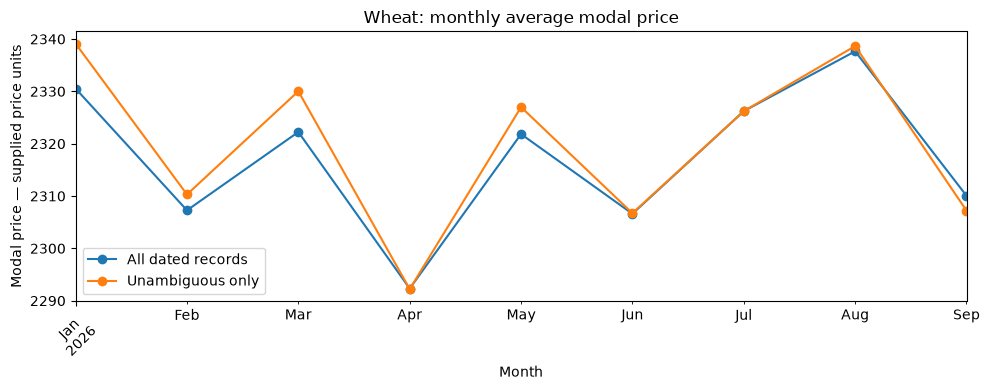

In [22]:
import matplotlib.pyplot as plt

wheat = df_prices_clean.loc[
    df_prices_clean["crop_name_clean"].eq("Wheat")
    & df_prices_clean["modal_price_clean"].notna()
    & df_prices_clean["date_clean"].notna()
].copy()

wheat["month"] = wheat["date_clean"].dt.to_period("M")

all_records = wheat.groupby("month")["modal_price_clean"].mean()

unambiguous = (
    wheat.loc[wheat["date_status"].eq("Parsed: unambiguous")]
    .groupby("month")["modal_price_clean"]
    .mean()
)

comparison = pd.concat(
    [
        all_records.rename("All dated records"),
        unambiguous.rename("Unambiguous only")
    ],
    axis=1
)

comparison.plot(marker="o", figsize=(10, 4))
plt.title("Wheat: monthly average modal price")
plt.xlabel("Month")
plt.ylabel("Modal price — supplied price units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## We retained these records under documented date-format conventions and preserved uncertainty flags for further analysis.

## Checking prices

In [24]:
df_prices_clean["record_id_clean"] = (
    df_prices_clean["record_id"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace("", pd.NA)
)

ids = df_prices_clean["record_id_clean"]
repeated = ids.notna() & ids.duplicated(keep=False)

print("Missing record IDs:", ids.isna().sum())
print("Rows with repeated IDs:", repeated.sum())

display(
    df_prices_clean.loc[
        repeated,
        ["record_id", "date", "mandi_id", "crop_name", "modal_price"]
    ].head(20)
)

Missing record IDs: 0
Rows with repeated IDs: 0


,record_id,date,mandi_id,crop_name,modal_price


## Inspecting MSP values by crop

In [25]:
msp_summary = (
    df_prices_clean.groupby("crop_name_clean")
    .agg(
        total_records=("record_id_clean", "size"),
        records_with_msp=("msp_clean", "count"),
        distinct_msp_values=("msp_clean", "nunique")
    )
)

msp_summary["missing_msp"] = (
    msp_summary["total_records"]
    - msp_summary["records_with_msp"]
)

display(msp_summary)

print("\nSupplied MSP values by crop:")
display(
    df_prices_clean[
        ["crop_name_clean", "msp_clean"]
    ]
    .dropna(subset=["msp_clean"])
    .drop_duplicates()
    .sort_values(["crop_name_clean", "msp_clean"])
)

,total_records,records_with_msp,distinct_msp_values,missing_msp
crop_name_clean,,,,
Cotton,1996,1605,1,391
Maize,2064,1663,1,401
Mustard,2011,1609,1,402
Rice,1932,1560,1,372
Sugarcane,2014,1592,1,422
Wheat,1983,1594,1,389



Supplied MSP values by crop:


,crop_name_clean,msp_clean
0,Cotton,6620.0
3,Maize,2090.0
11,Mustard,5650.0
2,Rice,2183.0
9,Sugarcane,3500.0
6,Wheat,2275.0


## Inspecting which crop has modal price and MSP

In [26]:
df_prices_clean["msp_comparison_status"] = np.select(
    [
        df_prices_clean["modal_price_clean"].isna().to_numpy(dtype=bool),
        df_prices_clean["msp_clean"].isna().to_numpy(dtype=bool)
    ],
    [
        "Unavailable: missing modal price",
        "Unavailable: missing MSP"
    ],
    default="Pair available: unit confirmation required"
)

display(
    df_prices_clean["msp_comparison_status"]
    .value_counts()
    .to_frame("row_count")
)

,row_count
msp_comparison_status,
Pair available: unit confirmation required,9131
Unavailable: missing MSP,2259
Unavailable: missing modal price,610


## Calculating the price–MSP gap and flag prices below the supplied MSP

In [28]:
eligible = (
    df_prices_clean["modal_price_clean"].notna()
    & df_prices_clean["msp_clean"].notna()
)

df_prices_clean["price_msp_gap"] = (
    df_prices_clean["modal_price_clean"]
    - df_prices_clean["msp_clean"]
).where(eligible)

df_prices_clean["below_supplied_msp"] = (
    df_prices_clean["price_msp_gap"]
    .lt(0)
    .astype("boolean")
    .where(eligible, pd.NA)
)

df_prices_clean.loc[eligible, "msp_comparison_status"] = (
    "Compared: common basis implied by challenge"
)

print("Eligible records:", int(eligible.sum()))
print(
    "Below supplied MSP:",
    int(df_prices_clean["below_supplied_msp"].sum())
)
print(
    "Below supplied MSP rate (%):",
    round(df_prices_clean["below_supplied_msp"].mean() * 100, 2)
)

Eligible records: 9131
Below supplied MSP: 3667
Below supplied MSP rate (%): 40.16


In [29]:
assert len(df_prices_clean) == 12000, "Unexpected row count."

ids = df_prices_clean["record_id_clean"]
assert ids.notna().all() and ids.is_unique, "Check record IDs."

assert df_prices_clean["crop_name_clean"].notna().all()
assert df_prices_clean["date_clean"].notna().all()

assert df_prices_clean["mandi_id_status"].isin(
    ["Matched", "Missing source ID"]
).all(), "Unexpected mandi ID issues."

price_columns = [
    "min_price_clean", "max_price_clean",
    "modal_price_clean", "msp_clean"
]

for column in price_columns:
    assert df_prices_clean[column].dropna().gt(0).all(), (
        f"Nonpositive values in {column}"
    )

assert not df_prices_clean[
    ["min_exceeds_max", "modal_below_min", "modal_above_max"]
].any().any(), "Price contradictions found."

eligible = (
    df_prices_clean["modal_price_clean"].notna()
    & df_prices_clean["msp_clean"].notna()
)

assert df_prices_clean["below_supplied_msp"].notna().equals(
    eligible
), "Comparison eligibility mismatch."

assert df_prices_clean.loc[
    eligible, "below_supplied_msp"
].eq(
    df_prices_clean.loc[eligible, "price_msp_gap"].lt(0)
).all(), "Below-MSP flags disagree with price gaps."

print("Prices validation passed.")
print("Records:", len(df_prices_clean))
print("Eligible comparisons:", int(eligible.sum()))
print(
    "Missing reporting districts:",
    df_prices_clean["district_clean"].isna().sum()
)

Prices validation passed.
Records: 12000
Eligible comparisons: 9131
Missing reporting districts: 2004


In [30]:
from pathlib import Path

# Final column names → working columns.
export_columns = {
    "record_id": "record_id_clean",
    "date": "date_clean",
    "mandi_id": "mandi_id_clean",
    "district": "district_clean",
    "crop_name": "crop_name_clean",
    "min_price": "min_price_clean",
    "max_price": "max_price_clean",
    "modal_price": "modal_price_clean",
    "msp": "msp_clean",
    "price_msp_gap": "price_msp_gap",
    "below_supplied_msp": "below_supplied_msp",
    "date_status": "date_status",
    "mandi_id_status": "mandi_id_status",
    "district_status": "district_status",
    "msp_comparison_status": "msp_comparison_status",
    "source_record_id": "record_id",
    "source_date": "date",
    "source_mandi_id": "mandi_id",
    "source_district": "district",
    "source_crop_name": "crop_name",
    "source_min_price": "min_price",
    "source_max_price": "max_price",
    "source_modal_price": "modal_price",
    "source_msp": "msp"
}

prices_export = df_prices_clean[
    list(export_columns.values())
].copy()

prices_export.columns = list(export_columns.keys())

output_folder = Path(
    "/Users/rohankhanna/Documents/datathon/cleaned_data"
)
output_folder.mkdir(parents=True, exist_ok=True)

output_file = output_folder / "price_and_msp_cleaned.csv"

prices_export.to_csv(
    output_file,
    index=False,
    na_rep="NA",
    date_format="%Y-%m-%d",
    encoding="utf-8-sig"
)

print("Saved:", output_file)

Saved: /Users/rohankhanna/Documents/datathon/cleaned_data/price_and_msp_cleaned.csv
